In [3]:
import os

# Oya dataset eke thiyena files list karanna
dataset_path = "/kaggle/input/datasets/whitedragonkoya/stone-data-set"
print(os.listdir(dataset_path))

['valid', 'train']


In [6]:
import os

# Kaggle input folders list karanna
print(os.listdir("/kaggle/input/"))

['datasets']


In [8]:
import os

print(os.listdir("/kaggle/input/datasets/"))

['whitedragonkoya']


In [9]:
import os

print(os.listdir("/kaggle/input/datasets/whitedragonkoya/"))

['epoch-files', 'stone-data-set']


In [11]:
import os, shutil

# ============================================
# 1. Epoch files path check karanna
# ============================================
print(os.listdir("/kaggle/input/datasets/whitedragonkoya/epoch-files/"))

['epoch80.pt', 'last.pt', 'epoch0.pt', 'epoch60.pt', 'epoch10.pt', 'epoch70.pt', 'epoch90.pt', 'epoch30.pt', 'epoch20.pt', 'epoch40.pt', 'epoch110.pt', 'best.pt', 'epoch50.pt', 'epoch100.pt']


In [12]:
import os, shutil

# ============================================
# 1. Checkpoint copy karanna
# ============================================
LAST_PT_SRC = "/kaggle/input/datasets/whitedragonkoya/epoch-files/last.pt"
WEIGHTS_DIR = "/kaggle/working/Urinary_Stone_Project/Stone_Version_6-imagessize/weights/"

os.makedirs(WEIGHTS_DIR, exist_ok=True)
shutil.copy(LAST_PT_SRC, WEIGHTS_DIR + "last.pt")

print("✅ Checkpoint copied!")
print("Files:", os.listdir(WEIGHTS_DIR))

# ============================================
# 2. YAML file hadanawa
# ============================================
import yaml

data = {
    'path': '/kaggle/input/datasets/whitedragonkoya/stone-data-set',
    'train': 'train',
    'val': 'valid',
    'nc': 1,
    'names': ['stone']
}

with open('/kaggle/working/clean_data.yaml', 'w') as f:
    yaml.dump(data, f)

print("✅ YAML updated!")

✅ Checkpoint copied!
Files: ['last.pt']
✅ YAML updated!


In [15]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.0 MB/s eta 0:00:00a 0:00:01


In [16]:
import os
from ultralytics import YOLO

PROJECT = "/kaggle/working/Urinary_Stone_Project"
RUN_NAME = "Stone_Version_6-imagessize"
LAST_PT = os.path.join(PROJECT, RUN_NAME, "weights", "last.pt")

if os.path.exists(LAST_PT):
    print(f"🔄 Resume karanawa: {LAST_PT}")
    model = YOLO(LAST_PT)
    model.train(resume=True)
else:
    print("❌ last.pt nehe!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
🔄 Resume karanawa: /kaggle/working/Urinary_Stone_Project/Stone_Version_6-imagessize/weights/last.pt
Ultralytics 8.4.41 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/clean_data.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, emb

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/kaggle/working/Urinary_Stone_Project/Stone_Version_6-imagessize/results.csv')
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


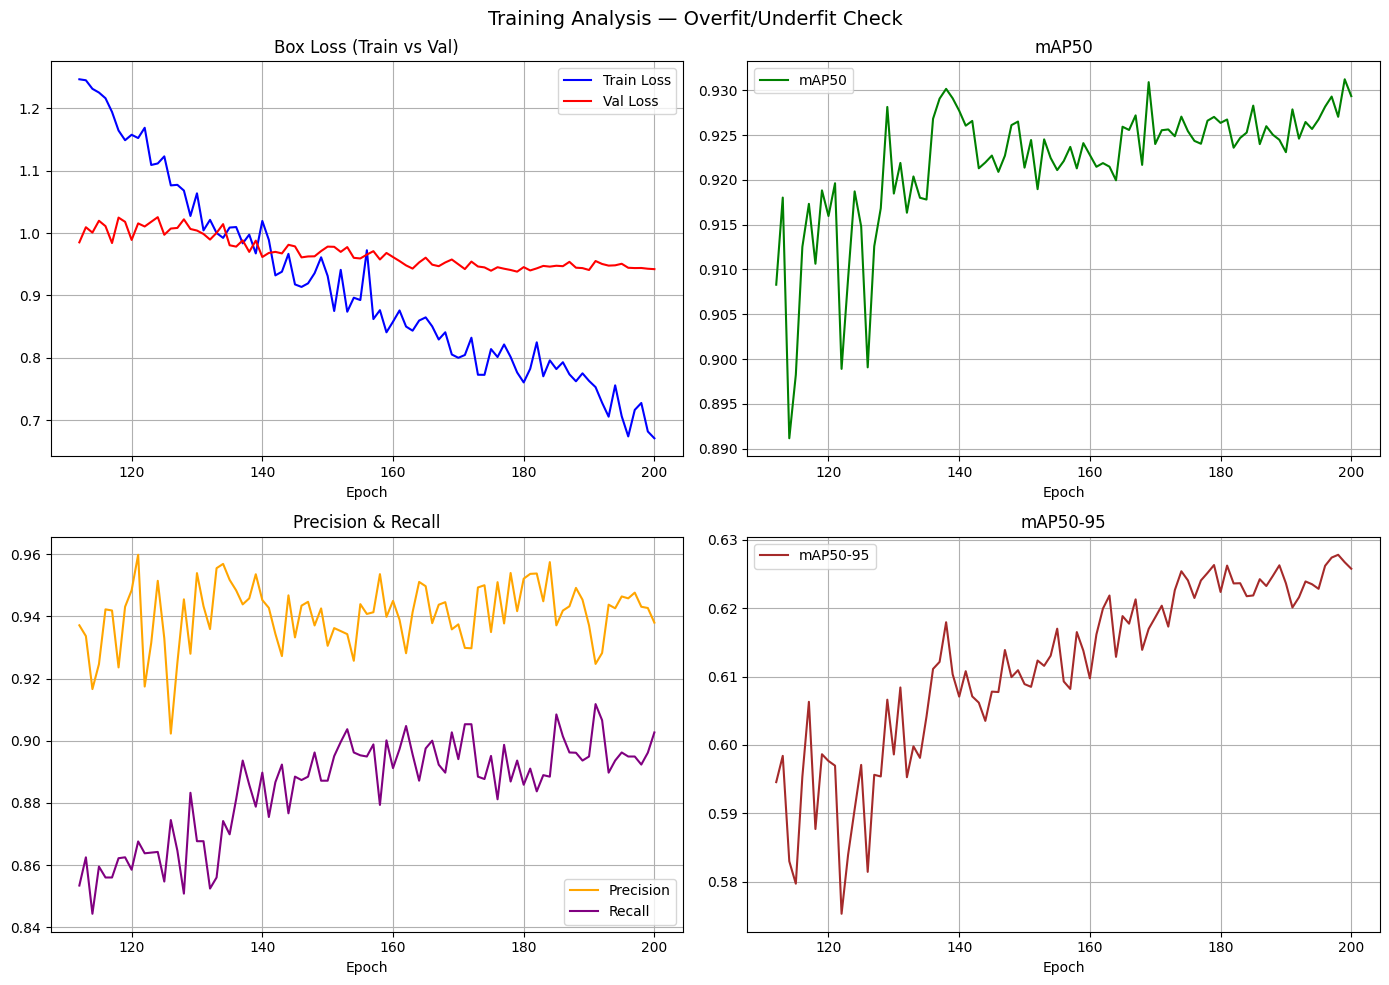

✅ Graph saved!


In [18]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/kaggle/working/Urinary_Stone_Project/Stone_Version_6-imagessize/results.csv')
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Training Analysis — Overfit/Underfit Check', fontsize=14)

# 1. Loss Curve
axes[0,0].plot(df['epoch'], df['train/box_loss'], label='Train Loss', color='blue')
axes[0,0].plot(df['epoch'], df['val/box_loss'], label='Val Loss', color='red')
axes[0,0].set_title('Box Loss (Train vs Val)')
axes[0,0].set_xlabel('Epoch')
axes[0,0].legend()
axes[0,0].grid(True)

# 2. mAP50
axes[0,1].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50', color='green')
axes[0,1].set_title('mAP50')
axes[0,1].set_xlabel('Epoch')
axes[0,1].legend()
axes[0,1].grid(True)

# 3. Precision & Recall
axes[1,0].plot(df['epoch'], df['metrics/precision(B)'], label='Precision', color='orange')
axes[1,0].plot(df['epoch'], df['metrics/recall(B)'], label='Recall', color='purple')
axes[1,0].set_title('Precision & Recall')
axes[1,0].set_xlabel('Epoch')
axes[1,0].legend()
axes[1,0].grid(True)

# 4. mAP50-95
axes[1,1].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP50-95', color='brown')
axes[1,1].set_title('mAP50-95')
axes[1,1].set_xlabel('Epoch')
axes[1,1].legend()
axes[1,1].grid(True)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150)
plt.show()
print("✅ Graph saved!")

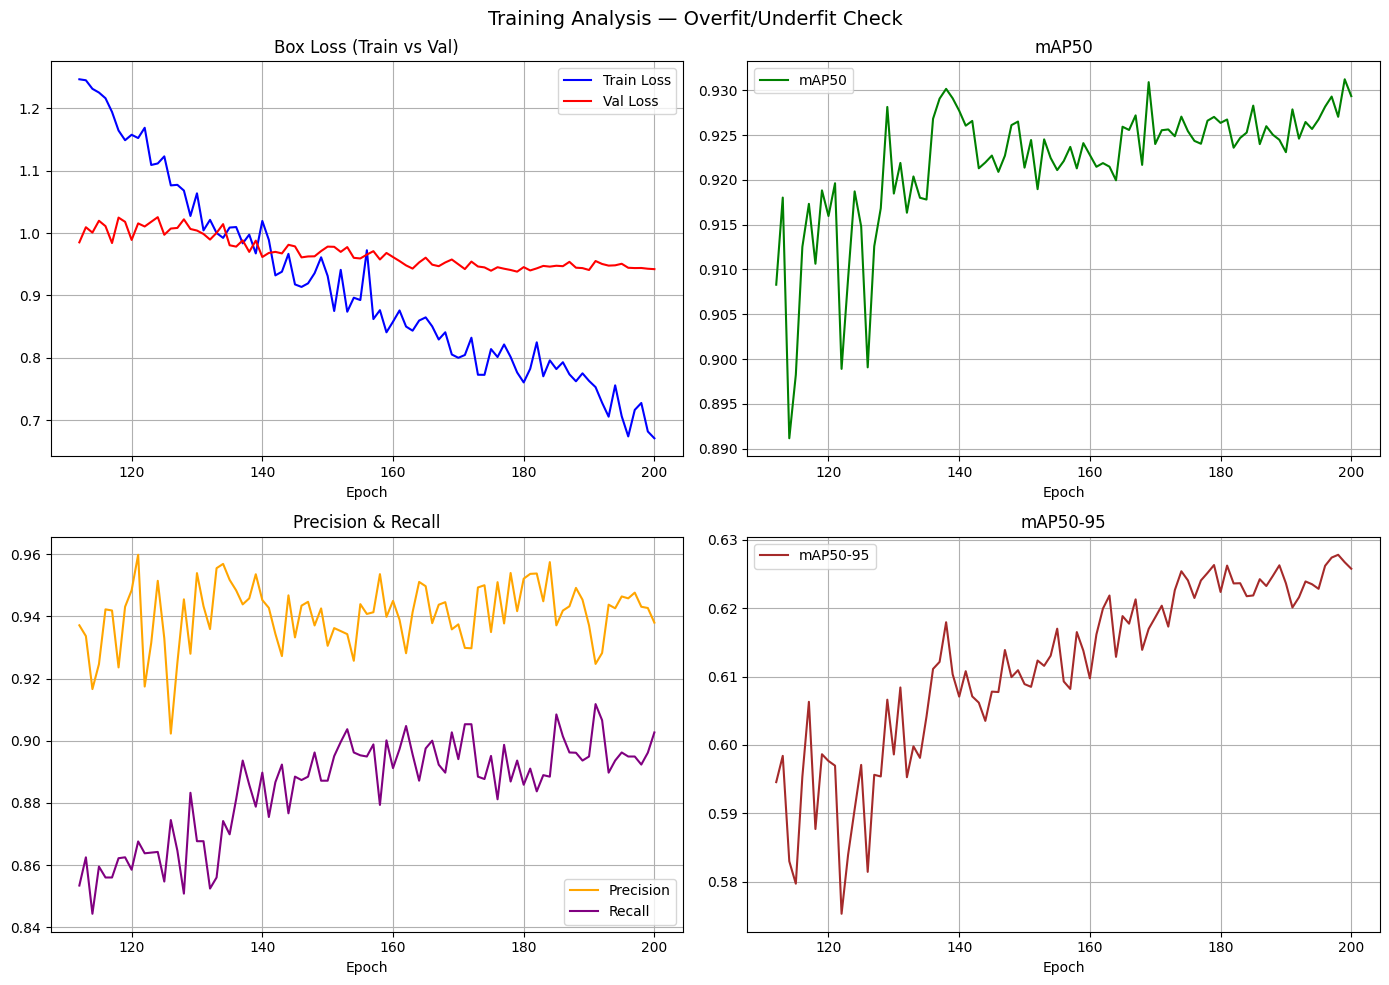

/kaggle/working/training_curves.jpg

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('/kaggle/working/Urinary_Stone_Project/Stone_Version_6-imagessize/results.csv')
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Training Analysis — Overfit/Underfit Check', fontsize=14)

axes[0,0].plot(df['epoch'], df['train/box_loss'], label='Train Loss', color='blue')
axes[0,0].plot(df['epoch'], df['val/box_loss'], label='Val Loss', color='red')
axes[0,0].set_title('Box Loss (Train vs Val)')
axes[0,0].set_xlabel('Epoch')
axes[0,0].legend()
axes[0,0].grid(True)

axes[0,1].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50', color='green')
axes[0,1].set_title('mAP50')
axes[0,1].set_xlabel('Epoch')
axes[0,1].legend()
axes[0,1].grid(True)

axes[1,0].plot(df['epoch'], df['metrics/precision(B)'], label='Precision', color='orange')
axes[1,0].plot(df['epoch'], df['metrics/recall(B)'], label='Recall', color='purple')
axes[1,0].set_title('Precision & Recall')
axes[1,0].set_xlabel('Epoch')
axes[1,0].legend()
axes[1,0].grid(True)

axes[1,1].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP50-95', color='brown')
axes[1,1].set_title('mAP50-95')
axes[1,1].set_xlabel('Epoch')
axes[1,1].legend()
axes[1,1].grid(True)

plt.tight_layout()

# ✅ JPG widihata save karanawa
plt.savefig('/kaggle/working/training_curves.jpg', dpi=150, format='jpeg', bbox_inches='tight')
plt.show()

from IPython.display import FileLink
FileLink(r'training_curves.jpg')

In [21]:
import shutil
from IPython.display import FileLink

shutil.make_archive('Stone_Version_6-imagessize', 'zip', '/kaggle/working/Urinary_Stone_Project/Stone_Version_6-imagessize')

FileLink(r'Stone_Version_6-imagessize.zip')

/kaggle/working/Stone_Version_6-imagessize.zip

In [22]:
from ultralytics import YOLO
import os, pandas as pd

EPOCH_DIR = "/kaggle/input/datasets/whitedragonkoya/epoch-files/"
DATA_YAML = "/kaggle/working/clean_data.yaml"

results_list = []

epoch_files = sorted([f for f in os.listdir(EPOCH_DIR) if f.startswith('epoch') and f.endswith('.pt')])

for file in epoch_files:
    epoch_num = int(file.replace('epoch','').replace('.pt',''))
    model = YOLO(os.path.join(EPOCH_DIR, file))
    metrics = model.val(data=DATA_YAML, imgsz=1280, device=[0,1], verbose=False)
    
    results_list.append({
        'epoch': epoch_num,
        'mAP50': metrics.box.map50,
        'mAP50-95': metrics.box.map,
        'precision': metrics.box.mp,
        'recall': metrics.box.mr
    })
    print(f"✅ Epoch {epoch_num} done — mAP50: {metrics.box.map50:.3f}")

df = pd.DataFrame(results_list).sort_values('epoch')
df.to_csv('/kaggle/working/reconstructed_results.csv', index=False)
print(df)

Ultralytics 8.4.41 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
Model summary (fused): 113 layers, 43,607,379 parameters, 0 gradients, 164.8 GFLOPs
val: Fast image access ✅ (ping: 1.7±0.3 ms, read: 126.3±18.7 MB/s, size: 57.8 KB)
val: Scanning /kaggle/input/datasets/whitedragonkoya/stone-data-set/valid/labels... 339 images, 105 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 339/339 523.1it/s 0.6s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/whitedragonkoya/stone-data-set/valid is not writable, cache not saved.
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 34, len(boxes) = 771. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━

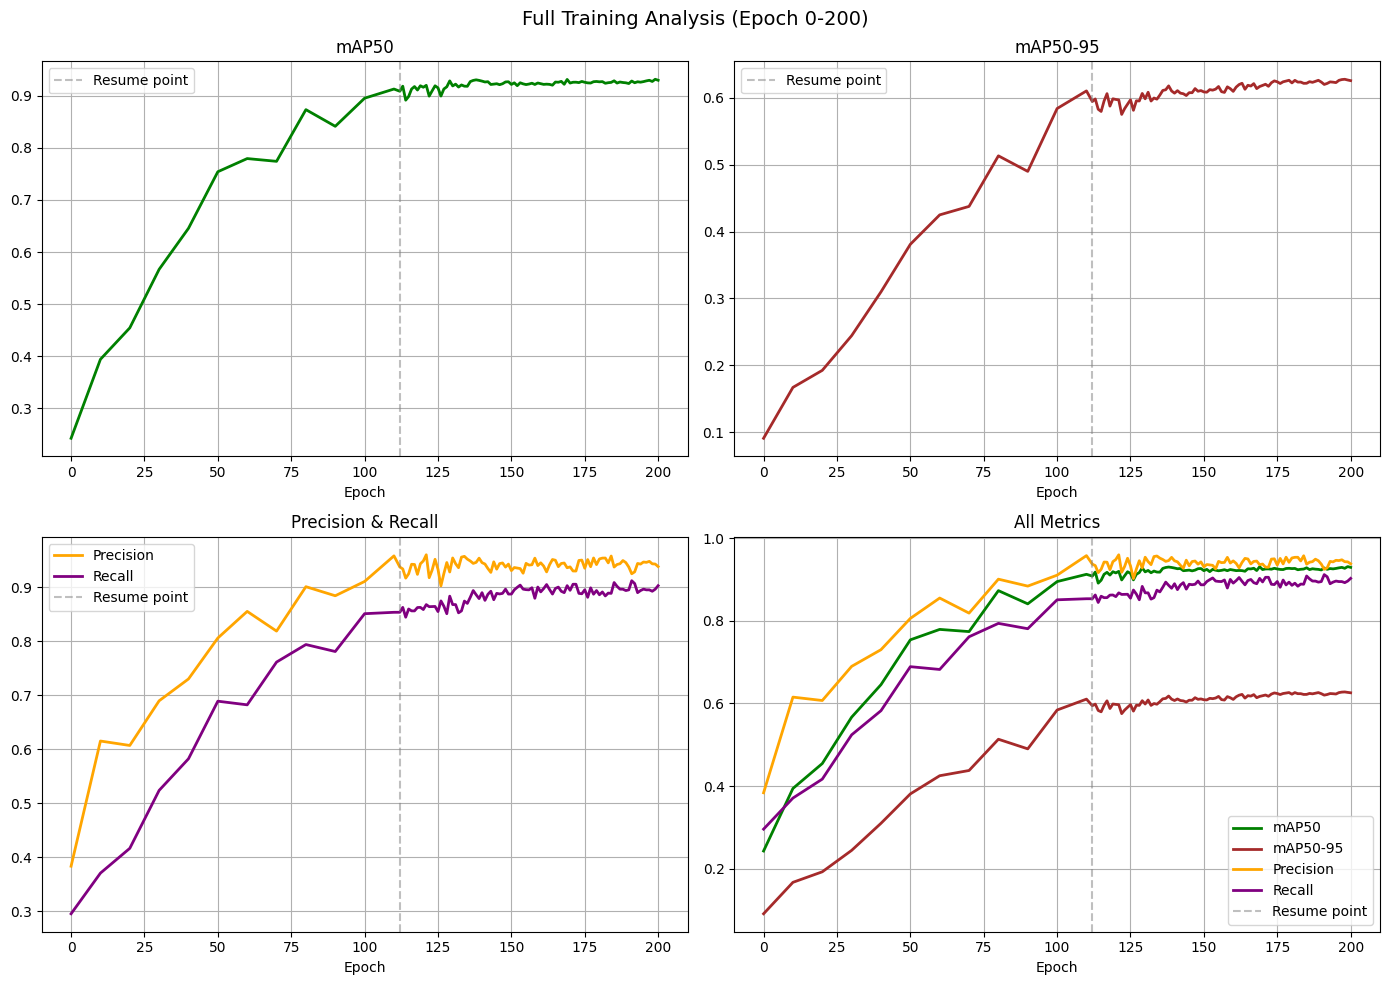

/kaggle/working/full_training_curves.jpg

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    'epoch': [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110],
    'mAP50': [0.242791, 0.394190, 0.454503, 0.566761, 0.645445, 0.753956, 0.779182, 0.773897, 0.873008, 0.841064, 0.894962, 0.912534],
    'mAP50_95': [0.090850, 0.166947, 0.192446, 0.244315, 0.309851, 0.380999, 0.424991, 0.437667, 0.513309, 0.490052, 0.584054, 0.610436],
    'precision': [0.383693, 0.615290, 0.607067, 0.689704, 0.730113, 0.805824, 0.855091, 0.818639, 0.900793, 0.884004, 0.910480, 0.957786],
    'recall': [0.295720, 0.370947, 0.416800, 0.523995, 0.582454, 0.688970, 0.682231, 0.761349, 0.793774, 0.780878, 0.850843, 0.853408]
})

# Session 2 data (epoch 112-200)
df2 = pd.read_csv('/kaggle/working/Urinary_Stone_Project/Stone_Version_6-imagessize/results.csv')
df2.columns = df2.columns.str.strip()
df2 = df2.rename(columns={
    'metrics/mAP50(B)': 'mAP50',
    'metrics/mAP50-95(B)': 'mAP50_95',
    'metrics/precision(B)': 'precision',
    'metrics/recall(B)': 'recall'
})

# Merge
full_df = pd.concat([
    df[['epoch','mAP50','mAP50_95','precision','recall']],
    df2[['epoch','mAP50','mAP50_95','precision','recall']]
]).sort_values('epoch').reset_index(drop=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Full Training Analysis (Epoch 0-200)', fontsize=14)

# 1. mAP50
axes[0,0].plot(full_df['epoch'], full_df['mAP50'], color='green', linewidth=2)
axes[0,0].axvline(x=112, color='gray', linestyle='--', alpha=0.5, label='Resume point')
axes[0,0].set_title('mAP50')
axes[0,0].set_xlabel('Epoch')
axes[0,0].legend()
axes[0,0].grid(True)

# 2. mAP50-95
axes[0,1].plot(full_df['epoch'], full_df['mAP50_95'], color='brown', linewidth=2)
axes[0,1].axvline(x=112, color='gray', linestyle='--', alpha=0.5, label='Resume point')
axes[0,1].set_title('mAP50-95')
axes[0,1].set_xlabel('Epoch')
axes[0,1].legend()
axes[0,1].grid(True)

# 3. Precision & Recall
axes[1,0].plot(full_df['epoch'], full_df['precision'], label='Precision', color='orange', linewidth=2)
axes[1,0].plot(full_df['epoch'], full_df['recall'], label='Recall', color='purple', linewidth=2)
axes[1,0].axvline(x=112, color='gray', linestyle='--', alpha=0.5, label='Resume point')
axes[1,0].set_title('Precision & Recall')
axes[1,0].set_xlabel('Epoch')
axes[1,0].legend()
axes[1,0].grid(True)

# 4. All metrics together
axes[1,1].plot(full_df['epoch'], full_df['mAP50'], label='mAP50', color='green', linewidth=2)
axes[1,1].plot(full_df['epoch'], full_df['mAP50_95'], label='mAP50-95', color='brown', linewidth=2)
axes[1,1].plot(full_df['epoch'], full_df['precision'], label='Precision', color='orange', linewidth=2)
axes[1,1].plot(full_df['epoch'], full_df['recall'], label='Recall', color='purple', linewidth=2)
axes[1,1].axvline(x=112, color='gray', linestyle='--', alpha=0.5, label='Resume point')
axes[1,1].set_title('All Metrics')
axes[1,1].set_xlabel('Epoch')
axes[1,1].legend()
axes[1,1].grid(True)

plt.tight_layout()
plt.savefig('/kaggle/working/full_training_curves.jpg', dpi=150, format='jpeg', bbox_inches='tight')
plt.show()

from IPython.display import FileLink
FileLink(r'full_training_curves.jpg')

In [26]:
df['mAP50_smooth'] = df['mAP50'].rolling(5).mean()

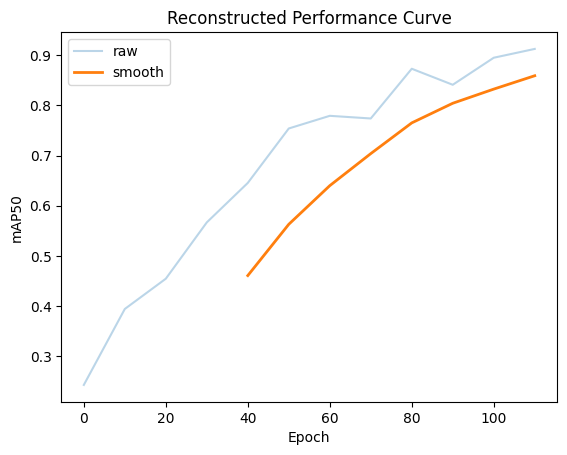

In [27]:
import matplotlib.pyplot as plt

plt.plot(df['epoch'], df['mAP50'], alpha=0.3, label='raw')
plt.plot(df['epoch'], df['mAP50_smooth'], label='smooth', linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("mAP50")
plt.legend()
plt.title("Reconstructed Performance Curve")
plt.show()

In [28]:
best_row = df.loc[df['mAP50'].idxmax()]
print(best_row)

epoch           110.000000
mAP50             0.912534
mAP50-95          0.610436
precision         0.957786
recall            0.853408
mAP50_smooth      0.859093
Name: 3, dtype: float64


In [32]:
import shutil
from IPython.display import FileLink

shutil.make_archive('Stone_Version_6-imagessize', 'zip', '/kaggle/working/Urinary_Stone_Project/Stone_Version_6-imagessize')

FileLink(r'Stone_Version_6-imagessize.zip')

/kaggle/working/Stone_Version_6-imagessize.zip

Testing image: images

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1359 /kaggle/input/datasets/whitedragonkoya/stone-data-set/train/images/1-1000-_JPEG.rf.3fd772ddfff9fd1031e3753a7767bb28.jpg: 1280x1280 1 stone, 137.9ms
image 2/1359 /kaggle/input/datasets/whitedragonkoya/stone-data-set/train/images/1-1000-_JPEG.rf.58adbcd8dcb0bd3dc0eaa595c671ffaa.jpg: 1280x1280 1 stone, 135.5ms
image 3/1359 /kaggle/input/datasets/whitedragonkoya/stone-data-set/train/images/1-1000-_JPEG.rf.b4d836d6fdcae5f5ac

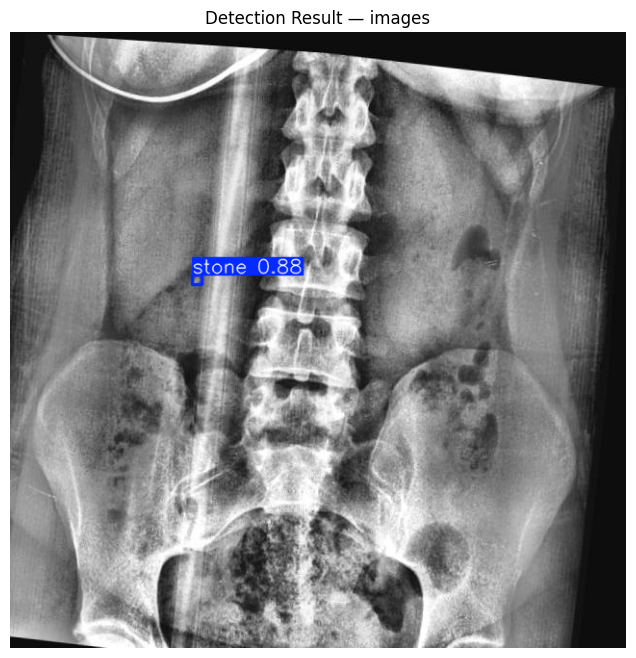


Detected stones: 1
  Stone 1: confidence = 0.881


In [33]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import os

# Best model eka load karanna
model = YOLO('/kaggle/working/Urinary_Stone_Project/Stone_Version_6-imagessize/weights/best.pt')

# Train folder eken random image ekak select karanna
import random
train_img_dir = '/kaggle/input/datasets/whitedragonkoya/stone-data-set/train'
images = os.listdir(train_img_dir)
random_img = random.choice(images)
img_path = os.path.join(train_img_dir, random_img)

print(f"Testing image: {random_img}")

# Predict karanna
results = model.predict(
    source=img_path,
    imgsz=1280,
    conf=0.25,
    save=False
)

# Result eka plot karanna
result_img = results[0].plot()
result_img_rgb = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 8))
plt.imshow(result_img_rgb)
plt.title(f'Detection Result — {random_img}')
plt.axis('off')
plt.savefig('/kaggle/working/test_result.jpg', dpi=150, bbox_inches='tight')
plt.show()

# Detection details
boxes = results[0].boxes
print(f"\nDetected stones: {len(boxes)}")
for i, box in enumerate(boxes):
    print(f"  Stone {i+1}: confidence = {box.conf[0]:.3f}")